# Credit Risk Classification — Corrected Project

This notebook analyzes the German Credit dataset (`credit_customers.csv`) and builds classification models to predict credit risk.

### Workflow
1. Load and inspect the data
2. Explore class balance and important categorical/numerical variables
3. Encode categorical variables
4. Split the data into training and testing sets
5. Train a Decision Tree
6. Train a class-weighted Decision Tree
7. Train a class-weighted Random Forest
8. Handle class imbalance with SMOTE
9. Train the final Random Forest
10. Compare model performance
11. Examine feature importance
12. Save the final model

### Visualizations
The notebook uses **Seaborn and Matplotlib** for:
- Target-class distribution
- Categorical feature distributions
- Risk rate by important categorical variables
- Numerical feature distributions
- Correlation heatmap
- Confusion matrices
- Model metric comparison
- Random Forest feature importance

> Place `credit_customers.csv` in the same folder as this notebook.


In [1]:
# =============================================
# 1. IMPORT LIBRARIES
# =============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style="whitegrid", context="notebook")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# =============================================
# 2. LOAD DATA
# =============================================

FILE_PATH = "credit_customers.csv"

try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{FILE_PATH}'. "
        "Place the CSV file in the same folder as this notebook."
    )

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [3]:
# =============================================
# 3. INITIAL DATA INSPECTION
# =============================================

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nTarget distribution:")
display(df["class"].value_counts().to_frame("count"))


Data types:


,dtype
checking_status,str
duration,float64
credit_history,str
purpose,str
credit_amount,float64
savings_status,str
employment,str
installment_commitment,float64
personal_status,str
other_parties,str



Dataset shape:
(1000, 21)

Missing values:


,missing_values
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0



Target distribution:


,count
class,
good,700
bad,300


In [4]:
# =============================================
# 4. UNIQUE VALUES IN CATEGORICAL FEATURES
# =============================================

for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(dropna=False).head(10))
    print("-" * 60)


checking_status: 4 unique values
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64
------------------------------------------------------------
credit_history: 5 unique values
credit_history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64
------------------------------------------------------------
purpose: 10 unique values
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64
------------------------------------------------------------
savings_status: 5 unique values
savings_status
<100                603
no

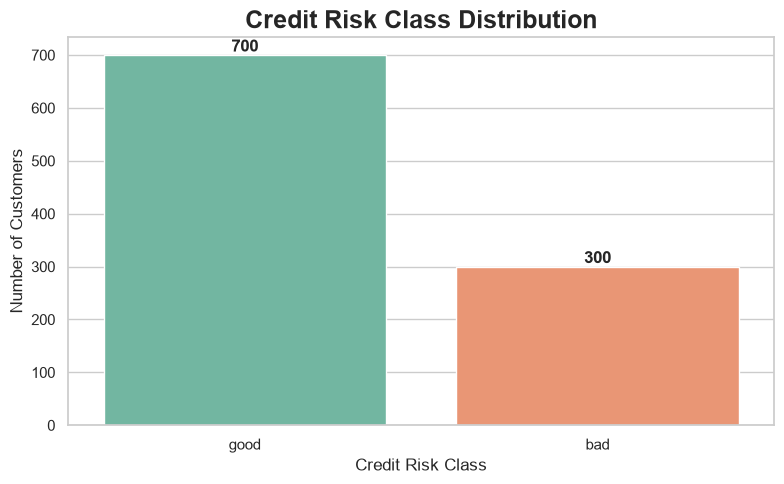

Class percentages:


,percentage
class,
good,70.0
bad,30.0


In [5]:
# =============================================
# 5. TARGET CLASS DISTRIBUTION
# =============================================

target_counts = df["class"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class",
    hue="class",
    palette="Set2",
    legend=False,
    ax=ax
)

for i, value in enumerate(target_counts.reindex(target_counts.index).values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title("Credit Risk Class Distribution",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Credit Risk Class")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print("Class percentages:")
display((target_counts / len(df) * 100).round(2).to_frame("percentage"))


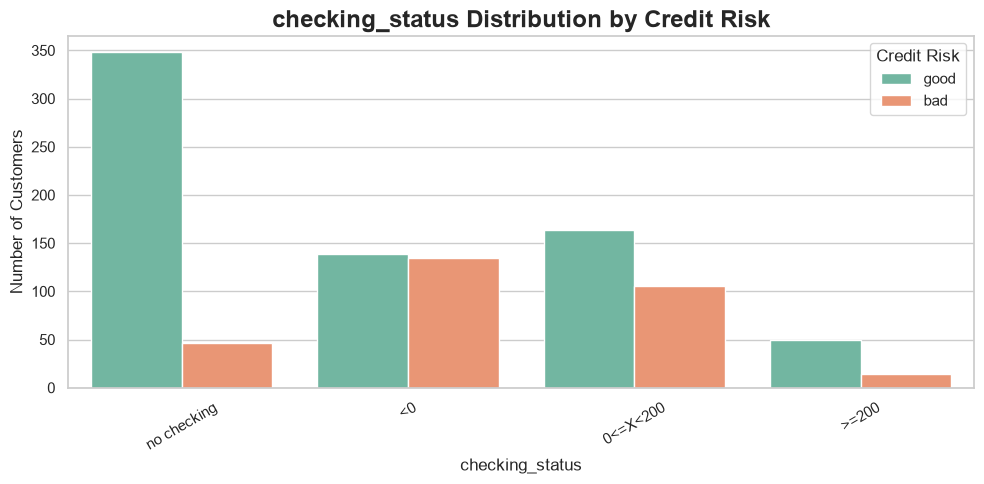

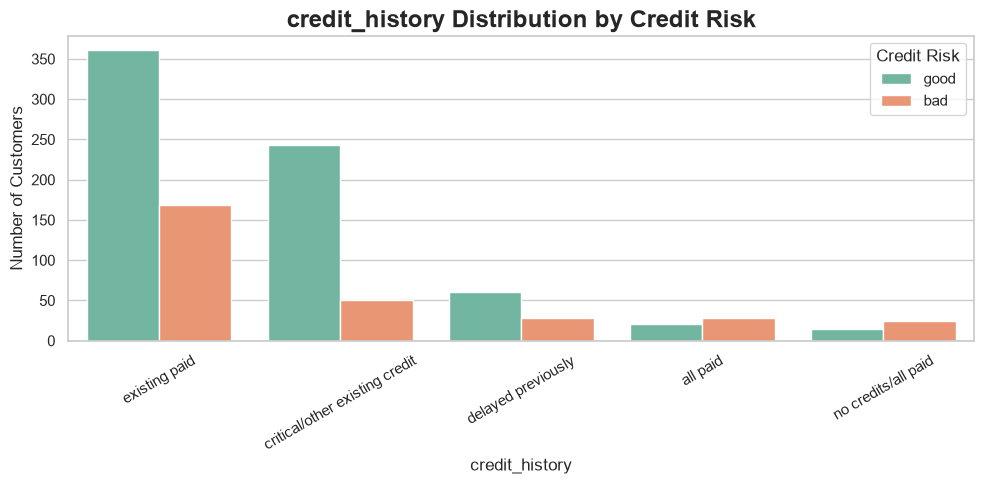

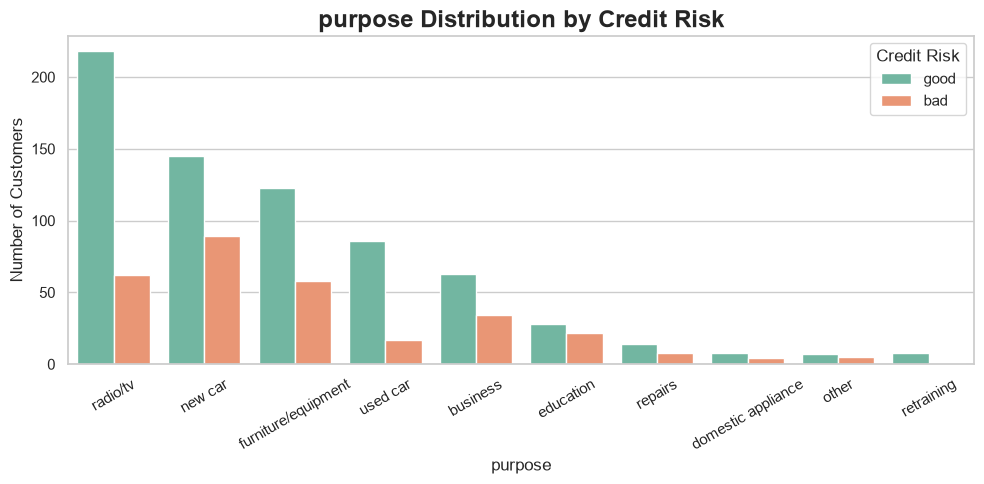

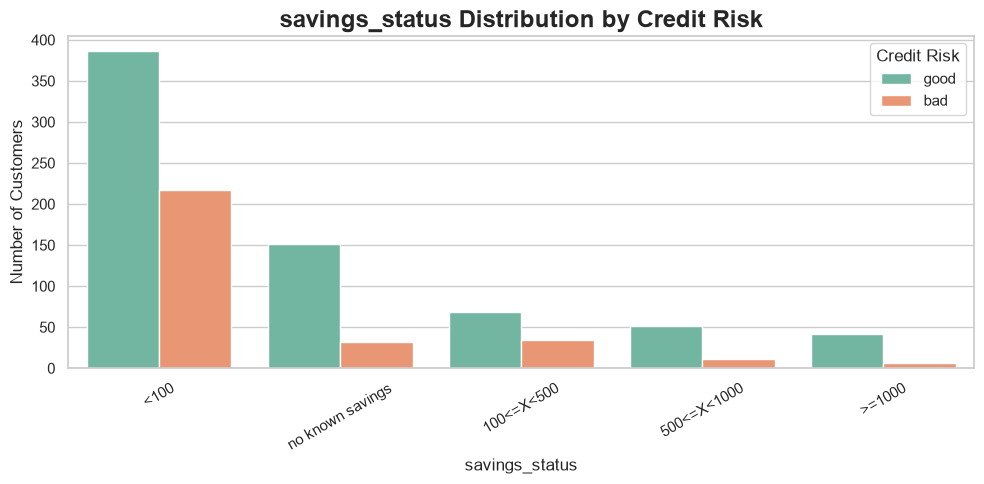

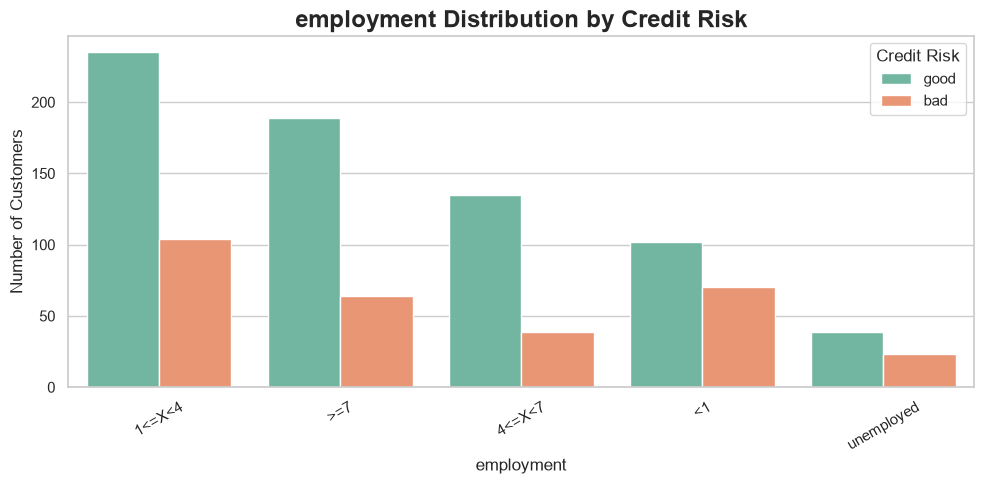

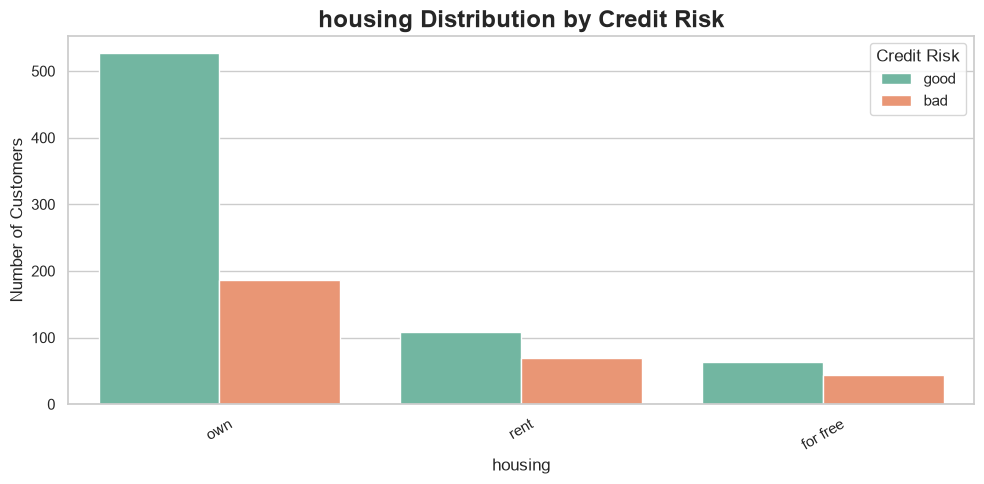

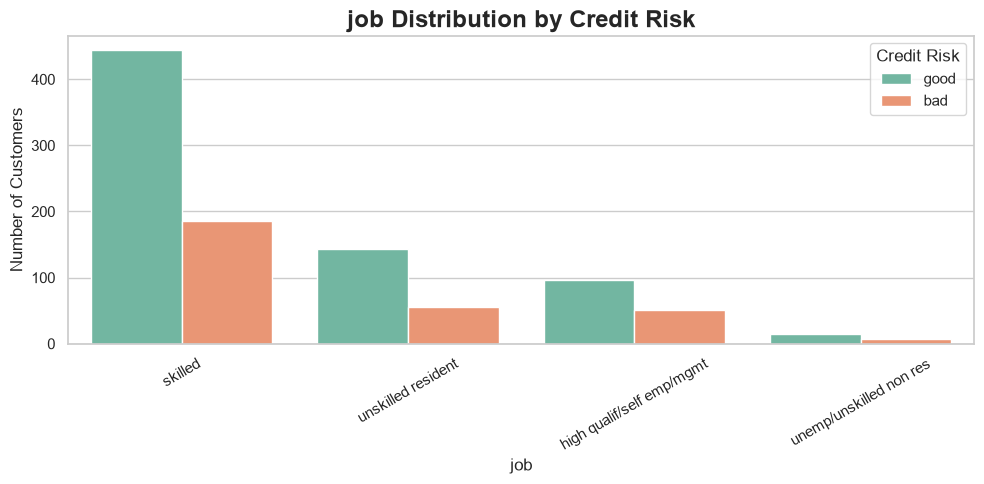

In [6]:
# =============================================
# 6. EXPLORATORY VISUALIZATIONS
# =============================================

# Important categorical variables from the dataset
categorical_features = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment",
    "housing",
    "job"
]

categorical_features = [
    col for col in categorical_features if col in df.columns
]

for feature in categorical_features:
    plt.figure(figsize=(10, 5))

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        hue="class",
        palette="Set2"
    )

    plt.title(f"{feature} Distribution by Credit Risk",
              fontsize=17, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30)
    plt.legend(title="Credit Risk")

    plt.tight_layout()
    plt.show()


Original target labels:
<ArrowStringArray>
['good', 'bad']
Length: 2, dtype: str


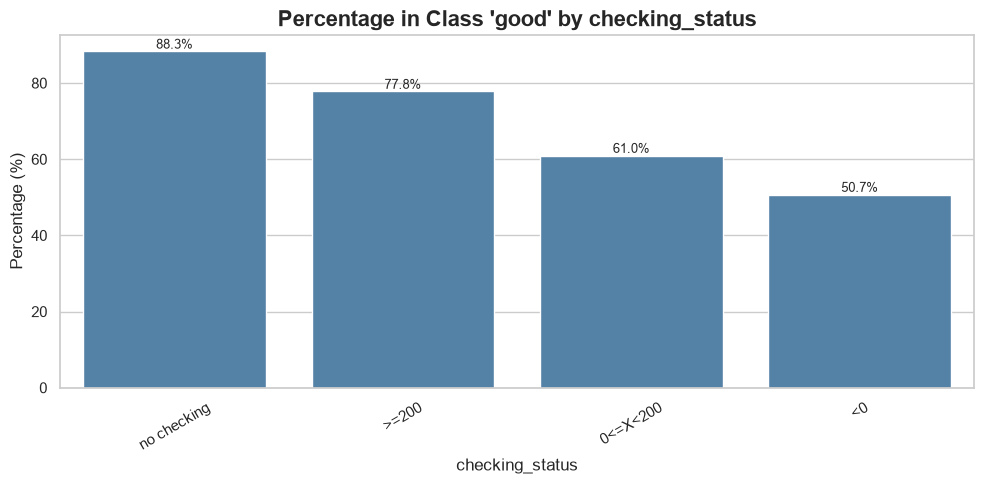

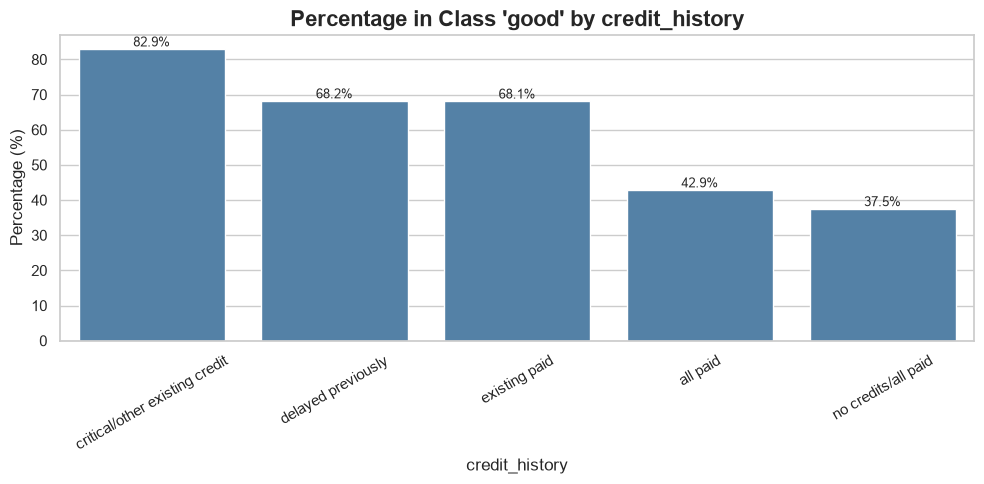

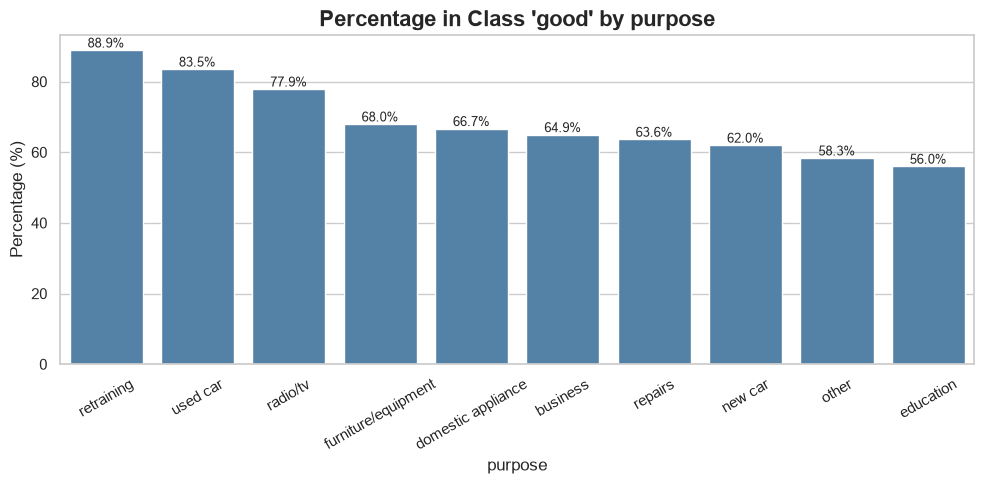

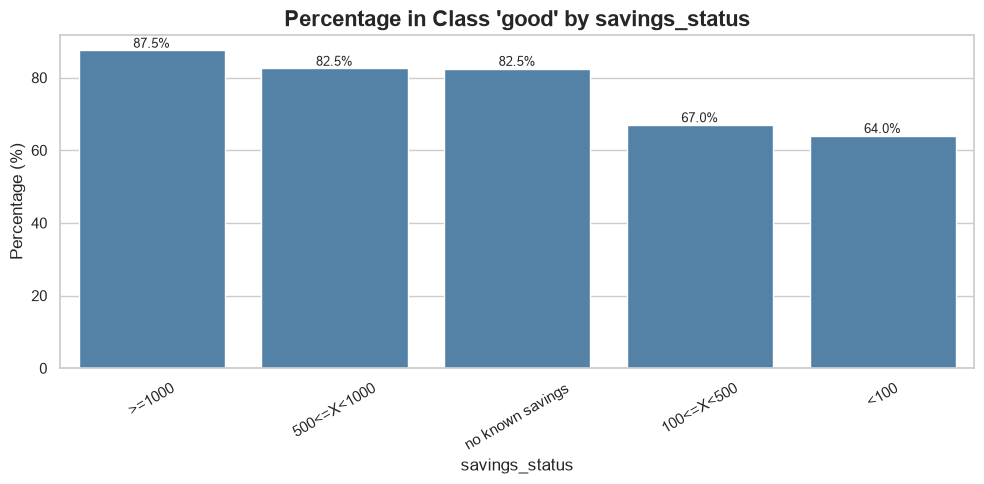

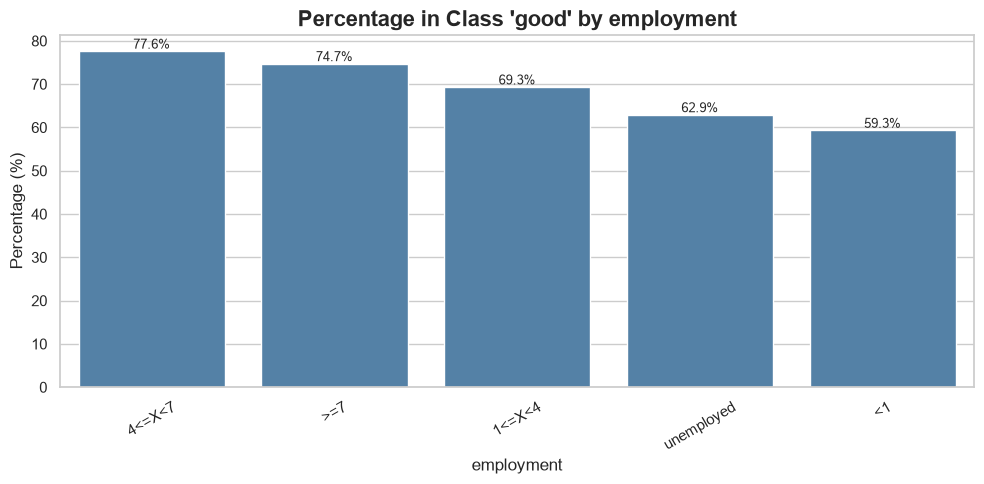

In [7]:
# =============================================
# 7. CREDIT RISK RATE BY CATEGORICAL FEATURE
# =============================================

# For each category, calculate the percentage of customers
# belonging to the first/positive target class.
#
# The exact meaning of the target labels is preserved from
# the original dataset and displayed below.

print("Original target labels:")
print(df["class"].unique())

# Keep the original labels before numerical encoding.
original_target = df["class"].copy()

for feature in categorical_features[:5]:
    rate_table = pd.crosstab(
        df[feature],
        df["class"],
        normalize="index"
    ) * 100

    # Use the last target category as the displayed risk category
    # without assuming a semantic label that is not in the source data.
    risk_class = rate_table.columns[-1]

    rates = rate_table[risk_class].sort_values(ascending=False)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=rates.index,
        y=rates.values,
        color="steelblue"
    )

    for i, value in enumerate(rates.values):
        plt.text(
            i,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(
        f"Percentage in Class '{risk_class}' by {feature}",
        fontsize=16,
        fontweight="bold"
    )
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


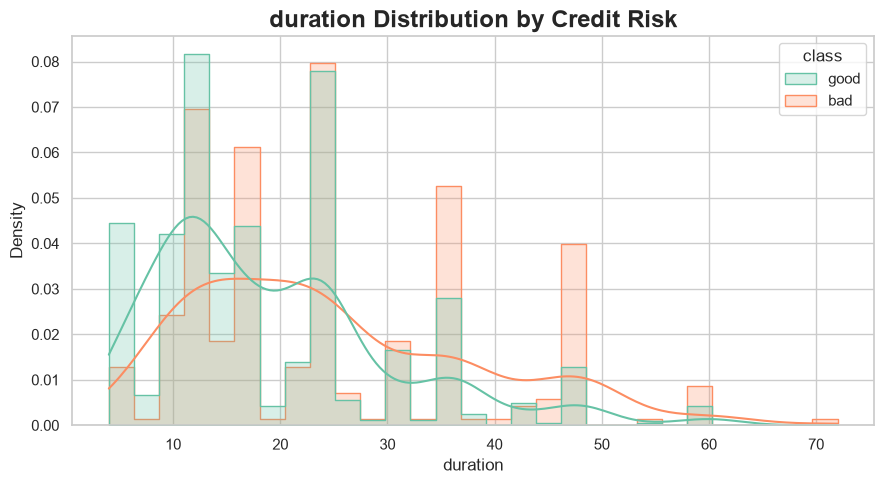

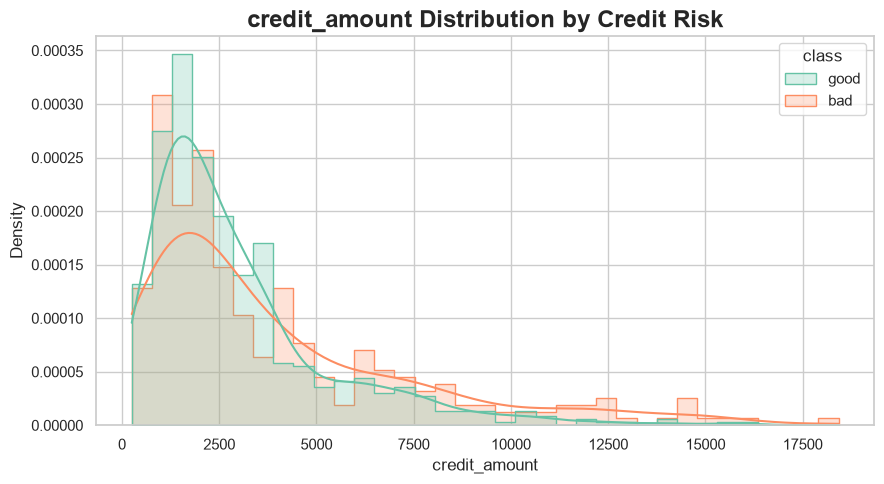

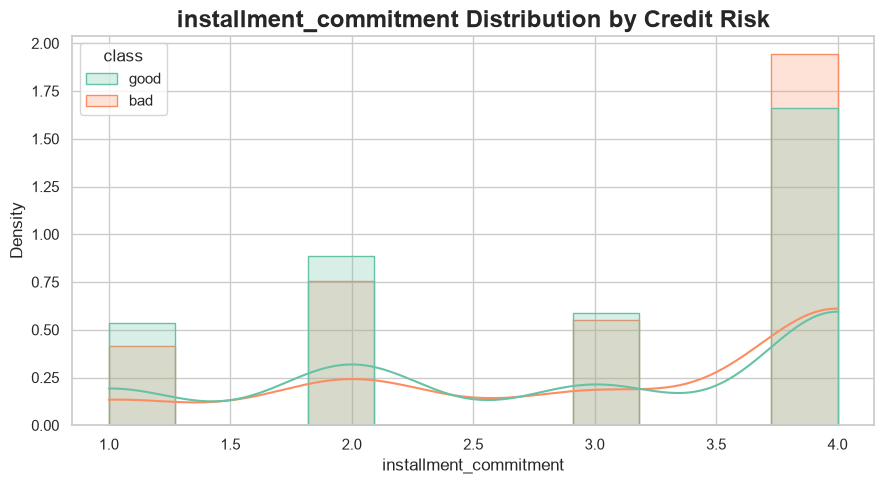

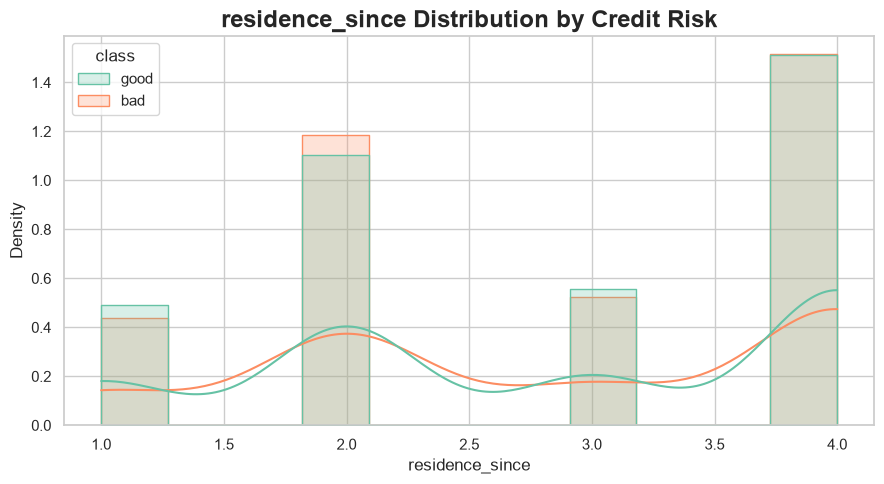

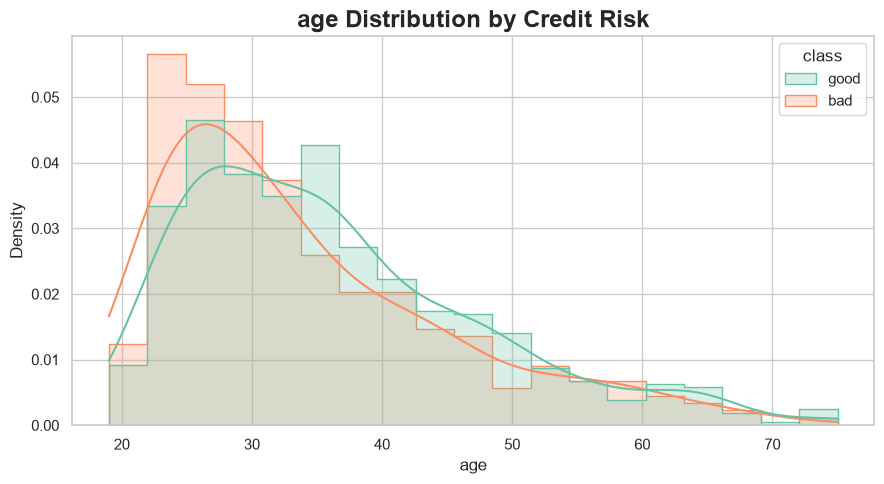

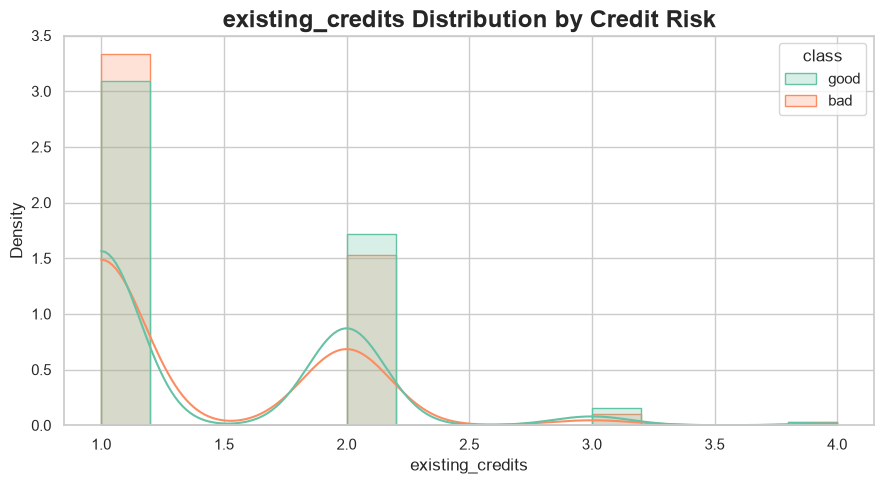

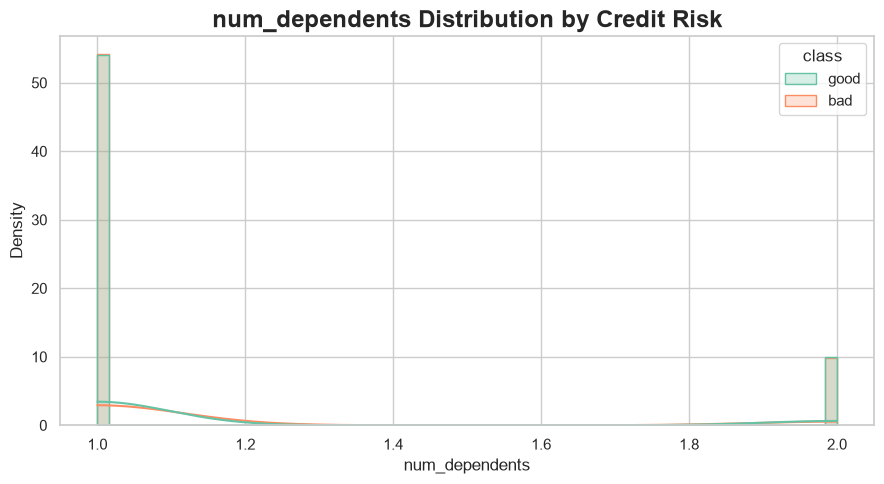

In [8]:
# =============================================
# 8. NUMERICAL FEATURE DISTRIBUTIONS
# =============================================

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Exclude target if it has already been numeric.
numeric_predictors = [
    col for col in numeric_columns if col != "class"
]

if numeric_predictors:
    for feature in numeric_predictors:
        fig, ax = plt.subplots(figsize=(9, 5))

        sns.histplot(
            data=df,
            x=feature,
            hue="class",
            kde=True,
            element="step",
            stat="density",
            common_norm=False,
            palette="Set2",
            ax=ax
        )

        ax.set_title(
            f"{feature} Distribution by Credit Risk",
            fontsize=17,
            fontweight="bold"
        )
        ax.set_xlabel(feature)
        ax.set_ylabel("Density")

        plt.tight_layout()
        plt.show()


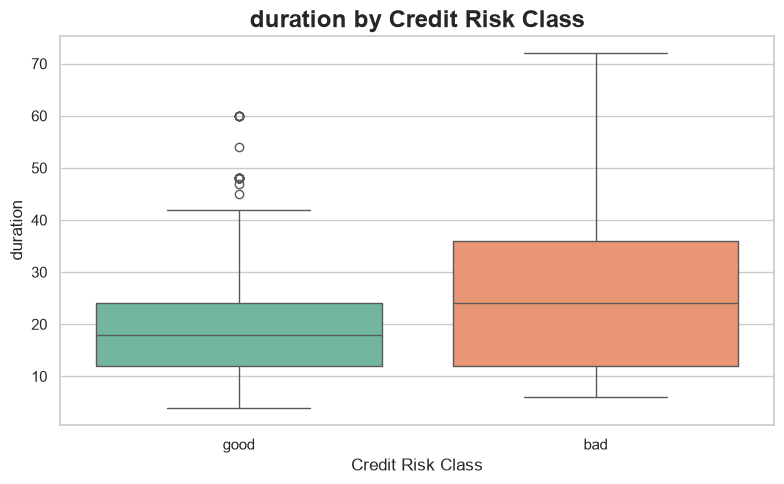

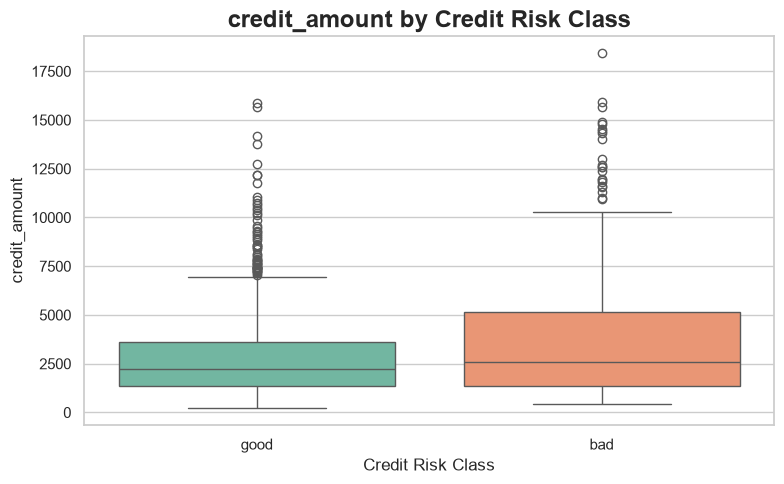

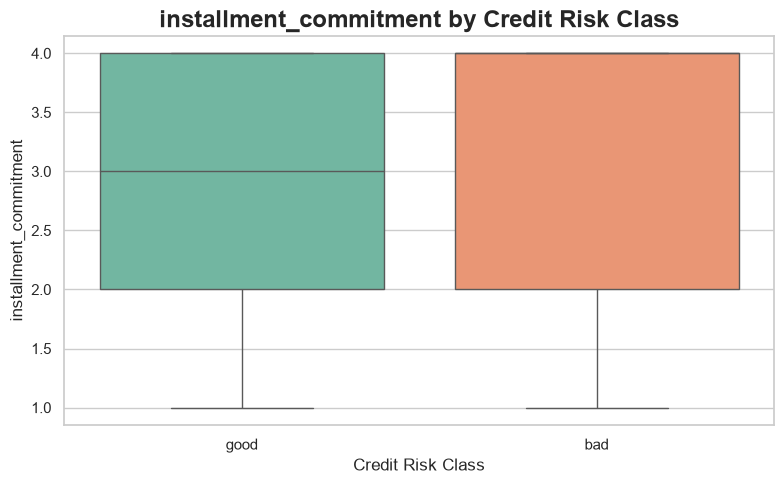

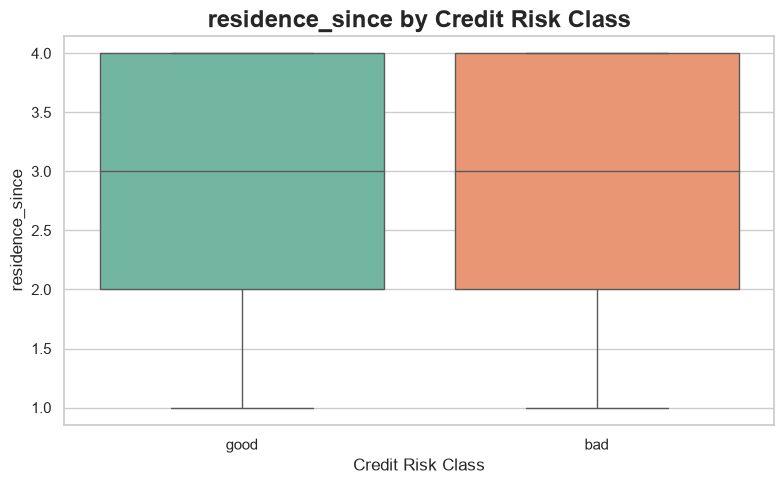

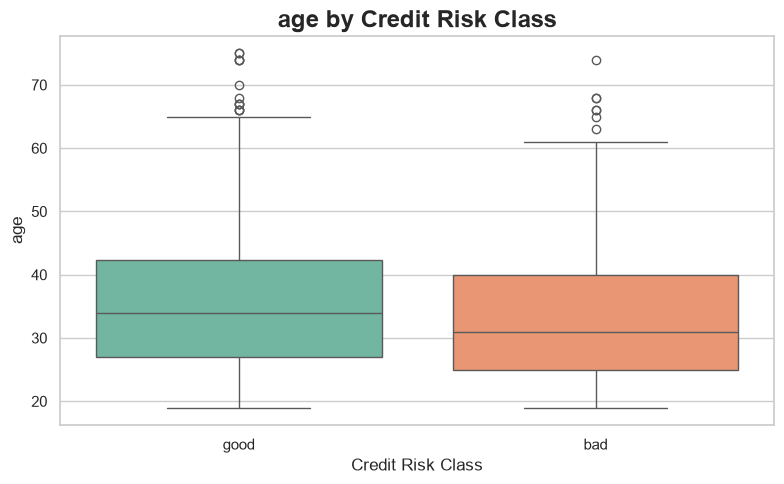

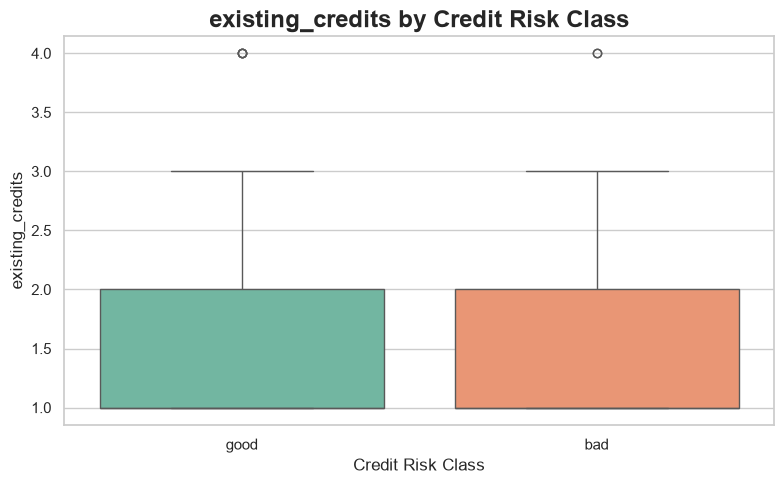

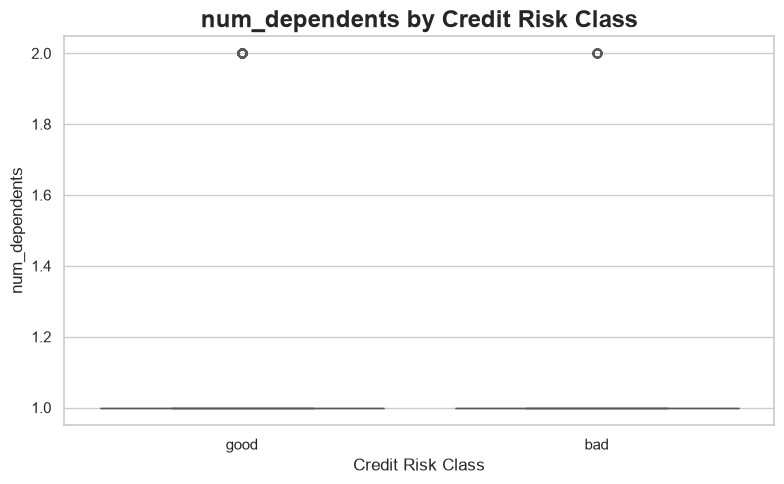

In [9]:
# =============================================
# 9. BOX PLOTS FOR NUMERICAL FEATURES
# =============================================

if numeric_predictors:
    for feature in numeric_predictors:
        plt.figure(figsize=(8, 5))

        sns.boxplot(
            data=df,
            x="class",
            y=feature,
            hue="class",
            palette="Set2",
            legend=False
        )

        plt.title(
            f"{feature} by Credit Risk Class",
            fontsize=17,
            fontweight="bold"
        )
        plt.xlabel("Credit Risk Class")
        plt.ylabel(feature)

        plt.tight_layout()
        plt.show()


In [10]:
# =============================================
# 10. ENCODE THE DATA
# =============================================

# Work on a copy so the original loaded dataframe remains
# available for exploratory analysis.
model_df = df.copy()

# Encode binary categorical columns exactly as in the original project.
binary_columns = [
    "own_telephone",
    "foreign_worker"
]

label_encoders = {}

for col in binary_columns:
    if col in model_df.columns:
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col])
        label_encoders[col] = le

# Encode target separately.
target_encoder = LabelEncoder()
model_df["class"] = target_encoder.fit_transform(model_df["class"])

print("Target mapping:")
for original, encoded in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(f"{original} -> {encoded}")

# One-hot encode remaining categorical predictors.
categorical_to_encode = model_df.select_dtypes(
    include="object"
).columns.tolist()

if categorical_to_encode:
    model_df = pd.get_dummies(
        model_df,
        columns=categorical_to_encode,
        dtype=int
    )

print("\nShape after encoding:", model_df.shape)
display(model_df.head())


Target mapping:
bad -> 0
good -> 1

Shape after encoding: (1000, 60)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,own_telephone,foreign_worker,class,...,other_payment_plans_bank,other_payment_plans_none,other_payment_plans_stores,housing_for free,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,1,1,1,...,0,1,0,0,1,0,0,1,0,0
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,1,1,...,0,1,0,0,1,0,0,0,0,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,1,1,...,0,1,0,1,0,0,0,1,0,0
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,0,1,0,...,0,1,0,1,0,0,0,1,0,0


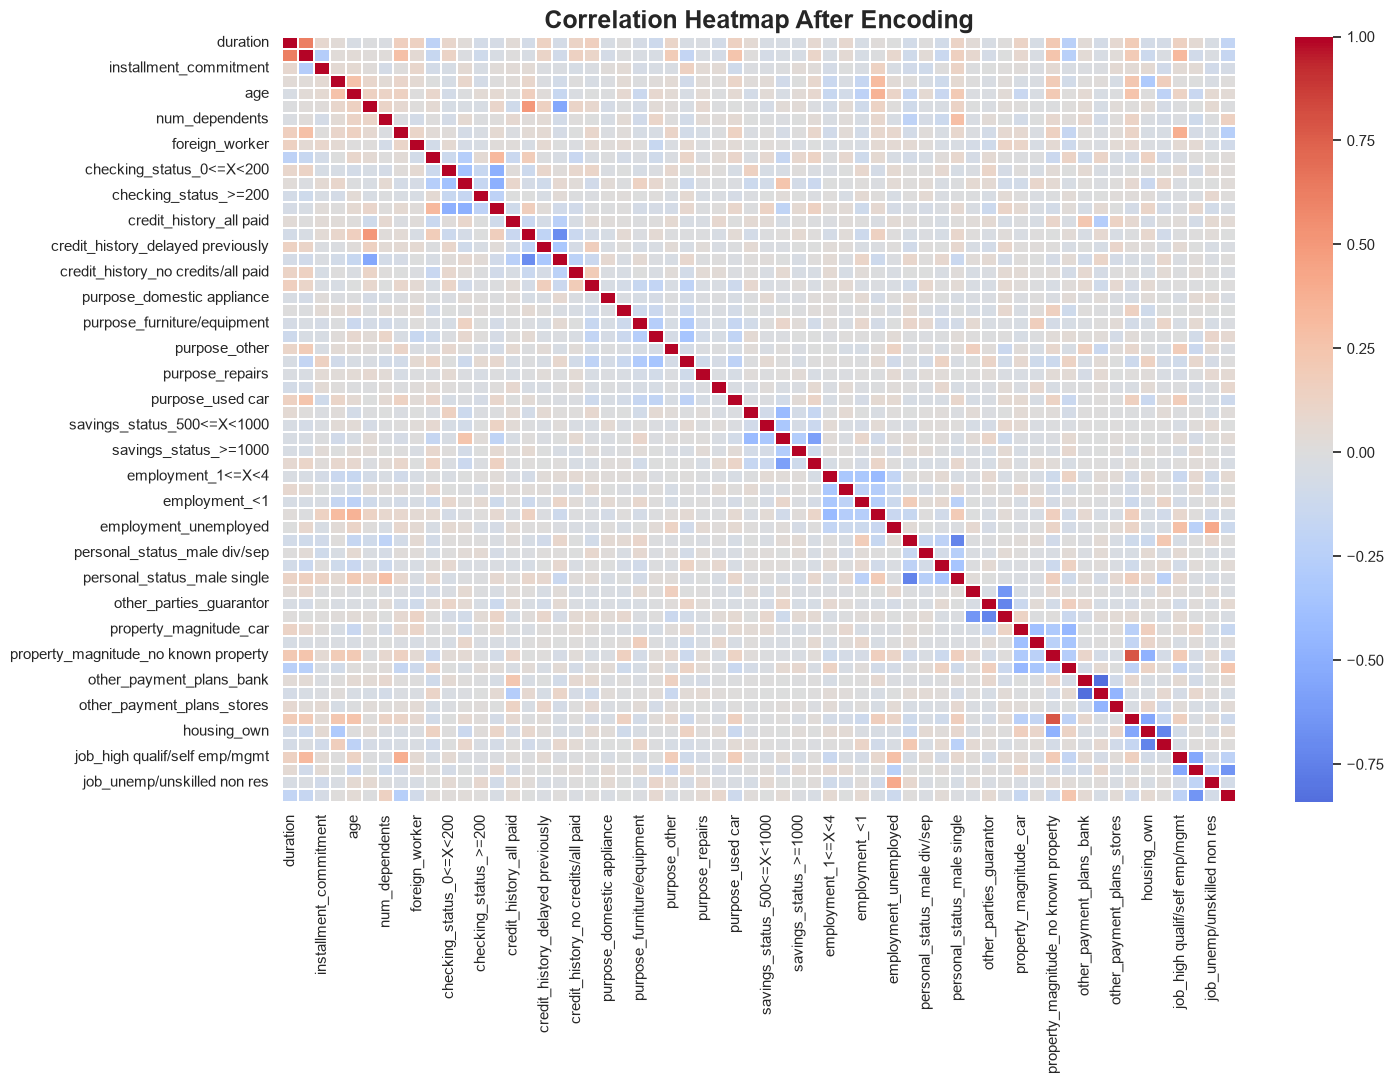

In [11]:
# =============================================
# 11. CORRELATION HEATMAP
# =============================================

correlation = model_df.corr(numeric_only=True)

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar=True
)

plt.title(
    "Correlation Heatmap After Encoding",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [12]:
# =============================================
# 12. TRAIN / TEST SPLIT
# =============================================

X = model_df.drop(columns=["class"])
y = model_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training size: (800, 59)
Testing size: (200, 59)

Training target distribution:
class
1    560
0    240
Name: count, dtype: int64

Testing target distribution:
class
1    140
0     60
Name: count, dtype: int64


In [13]:
# =============================================
# 13. HELPER FUNCTION FOR MODEL EVALUATION
# =============================================

results = {}

def evaluate_model(name, model, X_eval=X_test, y_eval=y_test):
    predictions = model.predict(X_eval)

    accuracy = accuracy_score(y_eval, predictions)
    precision = precision_score(y_eval, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_eval, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_eval, predictions, average="weighted", zero_division=0)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"===== {name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_eval, predictions, zero_division=0))

    return predictions


In [14]:
# =============================================
# 14. DECISION TREE
# =============================================

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = evaluate_model(
    "Decision Tree",
    decision_tree
)


===== Decision Tree =====
Accuracy : 0.6550
Precision: 0.6501
Recall   : 0.6550
F1 Score : 0.6524

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.40      0.41        60
           1       0.75      0.76      0.76       140

    accuracy                           0.66       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.65      0.66      0.65       200



In [15]:
# =============================================
# 15. CLASS-WEIGHTED DECISION TREE
# =============================================

balanced_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

balanced_tree.fit(X_train, y_train)

y_pred_balanced_tree = evaluate_model(
    "Balanced Decision Tree",
    balanced_tree
)


===== Balanced Decision Tree =====
Accuracy : 0.7000
Precision: 0.6842
Recall   : 0.7000
F1 Score : 0.6895

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        60
           1       0.76      0.83      0.79       140

    accuracy                           0.70       200
   macro avg       0.63      0.61      0.62       200
weighted avg       0.68      0.70      0.69       200



In [16]:
# =============================================
# 16. RANDOM FOREST
# =============================================

random_forest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# IMPORTANT:
# This prediction is generated by the Random Forest itself.
# The original notebook accidentally used an older Decision Tree
# prediction when printing the Random Forest report.
y_pred_rf = evaluate_model(
    "Balanced Random Forest",
    random_forest
)


===== Balanced Random Forest =====
Accuracy : 0.7350
Precision: 0.7417
Recall   : 0.7350
F1 Score : 0.7379

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.60      0.58        60
           1       0.82      0.79      0.81       140

    accuracy                           0.73       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200



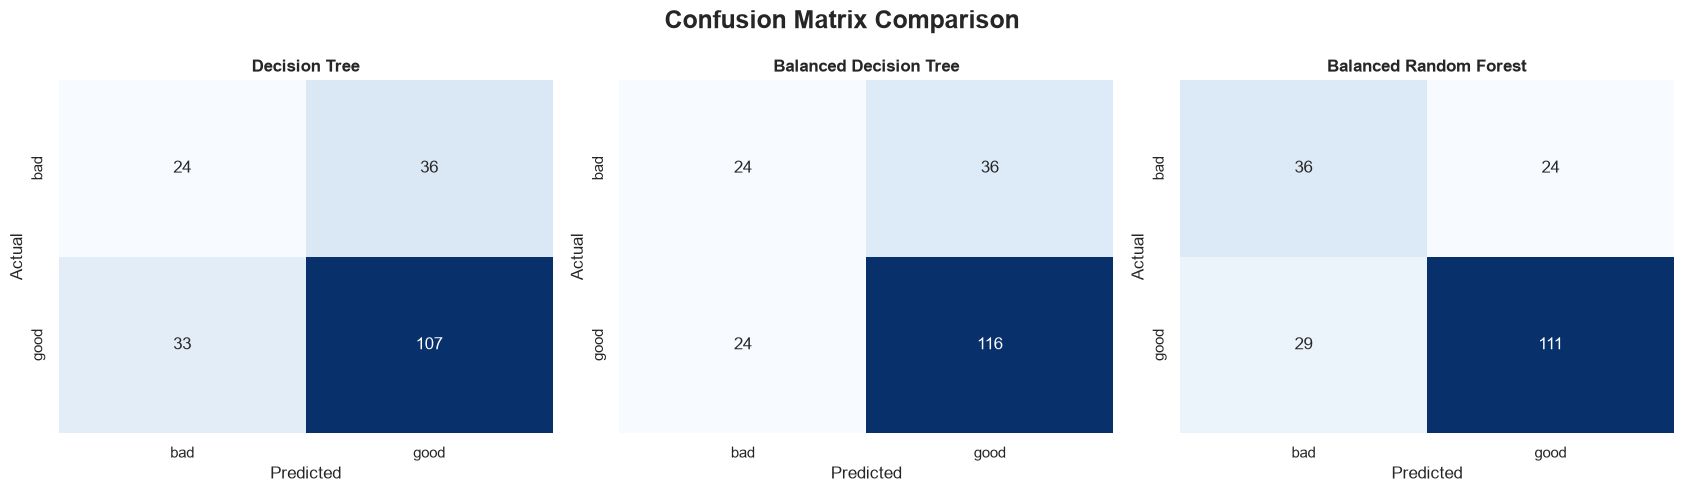

In [17]:
# =============================================
# 17. CONFUSION MATRICES
# =============================================

model_predictions = {
    "Decision Tree": y_pred_dt,
    "Balanced Decision Tree": y_pred_balanced_tree,
    "Balanced Random Forest": y_pred_rf
}

fig, axes = plt.subplots(
    1,
    len(model_predictions),
    figsize=(17, 5)
)

class_names = [
    str(label) for label in target_encoder.classes_
]

for ax, (name, predictions) in zip(
    axes,
    model_predictions.items()
):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


Class distribution in y_train:
class
1    560
0    240
Name: count, dtype: int64


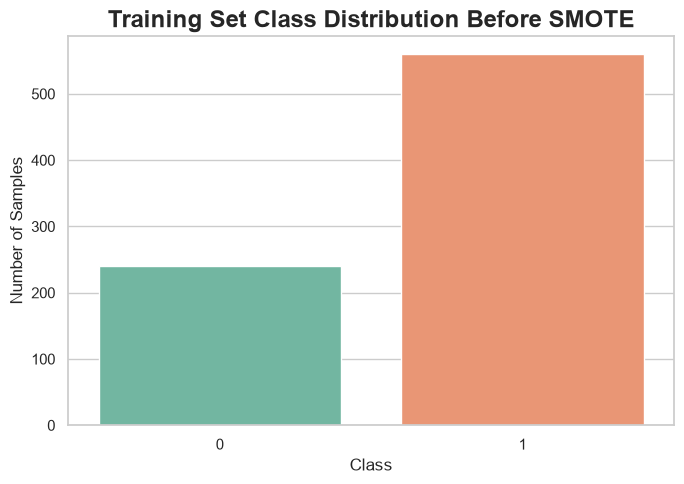

In [18]:
# =============================================
# 18. CHECK CLASS IMBALANCE
# =============================================

print("Class distribution in y_train:")
print(y_train.value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="Set2",
    legend=False
)

plt.title(
    "Training Set Class Distribution Before SMOTE",
    fontsize=17,
    fontweight="bold"
)
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()


Before SMOTE:
class
1    560
0    240
Name: count, dtype: int64

After SMOTE:
class
1    560
0    560
Name: count, dtype: int64


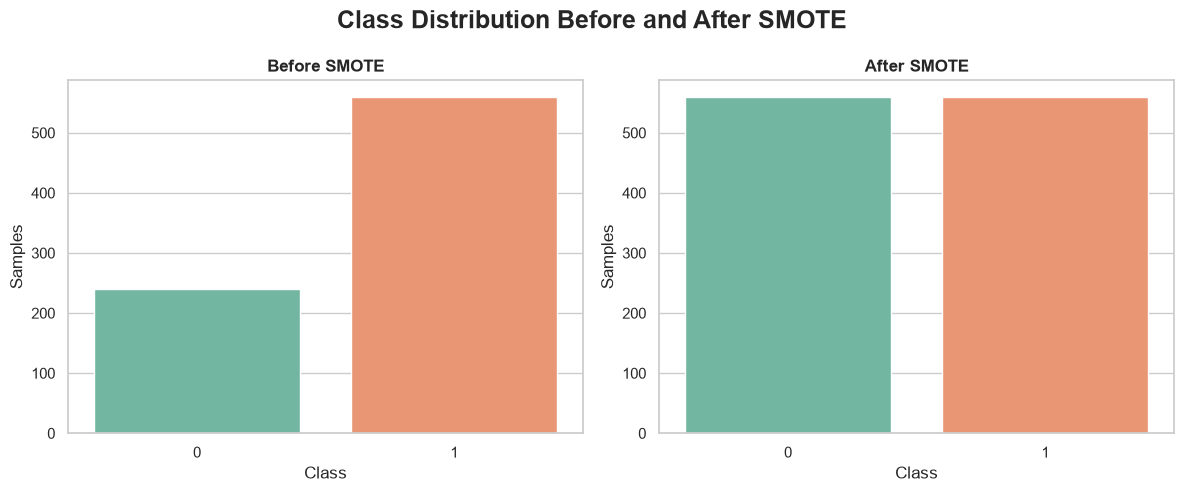

In [19]:
# =============================================
# 19. SMOTE OVERSAMPLING
# =============================================

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    raise ImportError(
        "imbalanced-learn is required for SMOTE. "
        "Install it with: pip install imbalanced-learn"
    )

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="Set2",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Before SMOTE", fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Samples")

sns.countplot(
    x=y_train_balanced,
    hue=y_train_balanced,
    palette="Set2",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("After SMOTE", fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Samples")

plt.suptitle(
    "Class Distribution Before and After SMOTE",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [20]:
# =============================================
# 20. FINAL RANDOM FOREST WITH SMOTE
# =============================================

smote_random_forest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=500,
    n_jobs=-1
)

smote_random_forest.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_smote_rf = evaluate_model(
    "Random Forest + SMOTE",
    smote_random_forest
)


===== Random Forest + SMOTE =====
Accuracy : 0.7200
Precision: 0.7040
Recall   : 0.7200
F1 Score : 0.7082

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.42      0.47        60
           1       0.77      0.85      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.63      0.64       200
weighted avg       0.70      0.72      0.71       200



,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.655,0.6501,0.655,0.6524
Balanced Decision Tree,0.700,0.6842,0.700,0.6895
Balanced Random Forest,0.735,0.7417,0.735,0.7379
Random Forest + SMOTE,0.720,0.7040,0.720,0.7082


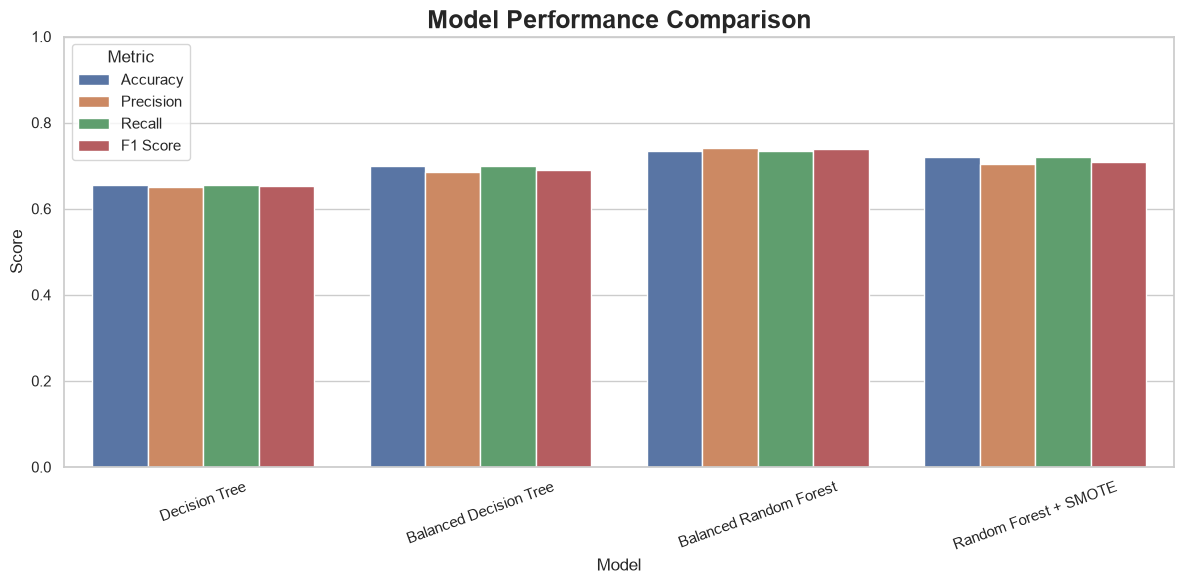

In [21]:
# =============================================
# 21. MODEL PERFORMANCE COMPARISON
# =============================================

results_df = pd.DataFrame(results).T

display(results_df.round(4))

plot_df = (
    results_df
    .reset_index()
    .rename(columns={"index": "Model"})
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Model Performance Comparison",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()


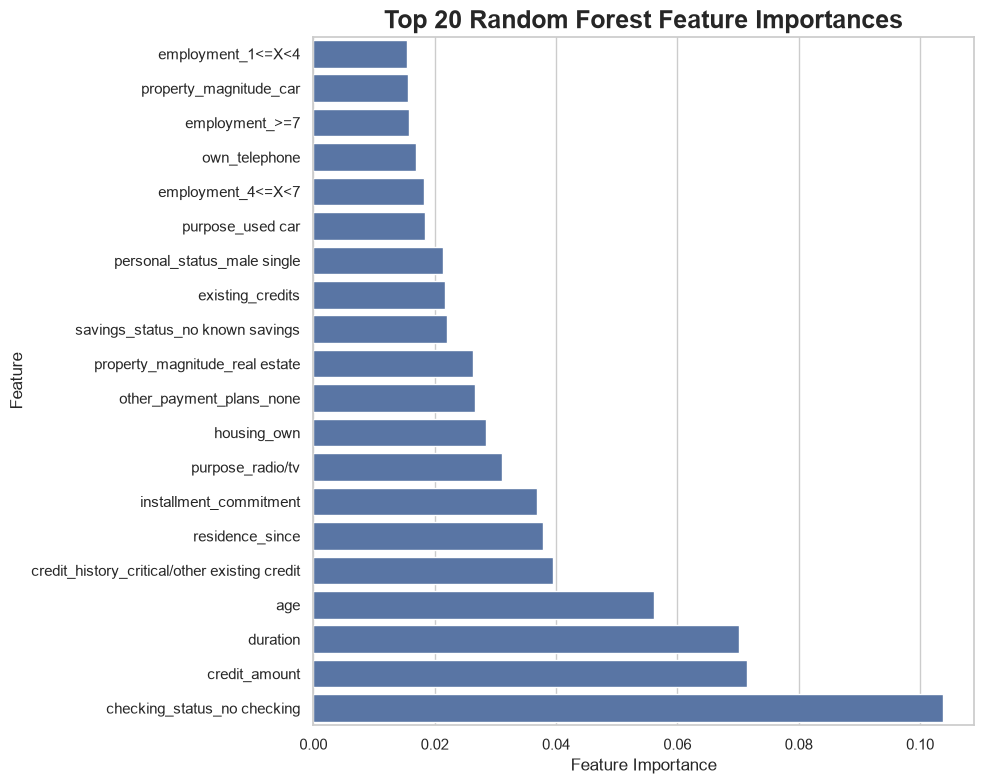

,importance
checking_status_no checking,0.103696
credit_amount,0.071454
duration,0.070161
age,0.056116
credit_history_critical/other existing credit,0.039415
residence_since,0.037907
installment_commitment,0.036794
purpose_radio/tv,0.031091
housing_own,0.028502
other_payment_plans_none,0.026561


In [22]:
# =============================================
# 22. RANDOM FOREST FEATURE IMPORTANCE
# =============================================

importance = pd.Series(
    smote_random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = min(20, len(importance))
top_features = importance.head(top_n).sort_values()

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title(
    f"Top {top_n} Random Forest Feature Importances",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(
    importance.head(top_n).to_frame("importance")
)


In [23]:
# =============================================
# 23. SAVE THE FINAL MODEL
# =============================================

import joblib

MODEL_FILE = "credit_risk_model.pkl"

joblib.dump(
    smote_random_forest,
    MODEL_FILE
)

print(f"Model saved successfully: {MODEL_FILE}")


Model saved successfully: credit_risk_model.pkl


## Final project checklist

Before using this project in a portfolio or interview, be able to explain:

- Why categorical variables need encoding
- Why the dataset is split before model training
- Why `stratify=y` is useful for an imbalanced classification problem
- What class imbalance means
- What `class_weight="balanced"` does
- What SMOTE does and why it should be applied only to the training data
- The difference between accuracy, precision, recall, and F1 score
- How to read a confusion matrix
- Why the Random Forest prediction must come from the Random Forest model itself
- What feature importance means and what it does **not** prove
